## 用于检查midi生成的wav和真实organ wav的差别
小样本、非配对、初步音频域检查

In [1]:
from pathlib import Path
import shutil
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from scipy.stats import ks_2samp, wasserstein_distance
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# =========================
# 1. 路径设置
# =========================

PROJECT_ROOT = Path(r"D:\organ-amt-generalization")

# 已有数据检查输出目录
PROCESSED_DIR = PROJECT_ROOT / r"data\processed\ex01_data_check"

# 已通过内容检查的 piano / synth organ 样本表
VALID_SAMPLES_PATH = PROCESSED_DIR / "valid_samples.csv"

REAL_AUDIO_DIR = Path(r"D:\organ-amt-generalization\data\raw\organ\real_organ_test")

# 输出目录，仍然放在 ex01_data_check 下面
REAL_VS_SYNTH_DIR = PROCESSED_DIR / "real_vs_synth_check"
REAL_VS_SYNTH_DIR.mkdir(parents=True, exist_ok=True)

# 非 wav 真实音频转换后的 wav 存放目录
REAL_WAV_DIR = REAL_VS_SYNTH_DIR / "real_wav"
REAL_WAV_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_DIR = REAL_VS_SYNTH_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COMPARE_SAMPLES_PATH = REAL_VS_SYNTH_DIR / "real_vs_synth_samples.csv"
FEATURE_TABLE_PATH = REAL_VS_SYNTH_DIR / "real_vs_synth_feature_table.csv"
FEATURE_SUMMARY_PATH = REAL_VS_SYNTH_DIR / "real_vs_synth_feature_summary.csv"
FEATURE_DISTANCE_PATH = REAL_VS_SYNTH_DIR / "real_vs_synth_feature_distance.csv"
HIST_FIG_PATH = FIGURE_DIR / "real_vs_synth_feature_histograms.png"
PCA_FIG_PATH = FIGURE_DIR / "real_vs_synth_pca.png"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("REAL_AUDIO_DIR:", REAL_AUDIO_DIR)
print("REAL_VS_SYNTH_DIR:", REAL_VS_SYNTH_DIR)

if not VALID_SAMPLES_PATH.exists():
    raise FileNotFoundError(f"找不到 valid_samples.csv: {VALID_SAMPLES_PATH}")

if not REAL_AUDIO_DIR.exists():
    raise FileNotFoundError(
        f"找不到真实管风琴音频目录: {REAL_AUDIO_DIR}\n"
        "请修改 REAL_AUDIO_DIR 为你的真实 organ 音频所在文件夹。"
    )


# =========================
# 2. ffmpeg 检查与音频转换
# =========================

AUDIO_EXTS = {".wav", ".flac", ".mp3", ".m4a", ".ogg"}

# 优先从系统 PATH 找 ffmpeg
FFMPEG_EXE = shutil.which("ffmpeg")

# 如果系统 PATH 找不到，则使用你之前下载的 ffmpeg
if FFMPEG_EXE is None:
    candidate = Path(r"D:\ffmpeg-8.1.1-essentials_build\bin\ffmpeg.exe")
    if candidate.exists():
        FFMPEG_EXE = str(candidate)

print("FFMPEG_EXE:", FFMPEG_EXE)


def convert_to_wav_if_needed(in_path, out_dir, sr=44100):
    """
    如果输入已经是 wav，直接返回原路径。
    如果是 m4a / mp3 / flac / ogg，则用 ffmpeg 转成 wav。
    """
    in_path = Path(in_path)

    if in_path.suffix.lower() == ".wav":
        return in_path

    if FFMPEG_EXE is None:
        raise FileNotFoundError(
            "找不到 ffmpeg。请先确认 ffmpeg 已加入 PATH，或修改 FFMPEG_EXE 为 ffmpeg.exe 的绝对路径。"
        )

    out_path = Path(out_dir) / f"{in_path.stem}.wav"
    out_path.parent.mkdir(parents=True, exist_ok=True)

    if out_path.exists():
        return out_path

    cmd = [
        FFMPEG_EXE,
        "-y",
        "-i", str(in_path),
        "-ar", str(sr),
        "-ac", "1",
        str(out_path),
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        raise RuntimeError(
            f"ffmpeg 转换失败: {in_path}\n\nSTDERR:\n{result.stderr[:2000]}"
        )

    return out_path


# =========================
# 3. 构造 real / synth 对比样本表
# =========================

valid_samples = pd.read_csv(VALID_SAMPLES_PATH)

required_cols = ["piece_id", "instrument", "audio_path"]
missing_cols = [c for c in required_cols if c not in valid_samples.columns]
if missing_cols:
    raise ValueError(f"valid_samples.csv 缺少必要字段: {missing_cols}")

# synth organ：来自 MIDI 合成的 organ wav
synth_df = valid_samples[valid_samples["instrument"] == "organ"].copy()
synth_df["sample_id"] = synth_df["piece_id"].astype(str)
synth_df["domain"] = "synth"
synth_df["audio_path"] = synth_df["audio_path"].astype(str)

synth_df = synth_df[["sample_id", "domain", "audio_path"]].copy()

# real organ：来自真实管风琴 wav / flac / mp3 / m4a
real_audio_files = sorted([
    p for p in REAL_AUDIO_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in AUDIO_EXTS
])

if len(real_audio_files) == 0:
    raise FileNotFoundError(f"真实管风琴目录中没有找到音频文件: {REAL_AUDIO_DIR}")

converted_real_paths = []

for p in real_audio_files:
    wav_path = convert_to_wav_if_needed(p, REAL_WAV_DIR, sr=44100)
    converted_real_paths.append(wav_path)

real_df = pd.DataFrame({
    "sample_id": [p.stem for p in converted_real_paths],
    "domain": "real",
    "audio_path": [str(p) for p in converted_real_paths],
})

compare_df = pd.concat([real_df, synth_df], ignore_index=True)

compare_df.to_csv(COMPARE_SAMPLES_PATH, index=False, encoding="utf-8-sig")

print("real samples :", len(real_df))
print("synth samples:", len(synth_df))
print("compare_df shape:", compare_df.shape)

display(compare_df.head())
display(compare_df["domain"].value_counts())

print("saved:", COMPARE_SAMPLES_PATH)



PROJECT_ROOT: D:\organ-amt-generalization
PROCESSED_DIR: D:\organ-amt-generalization\data\processed\ex01_data_check
REAL_AUDIO_DIR: D:\organ-amt-generalization\data\raw\organ\real_organ_test
REAL_VS_SYNTH_DIR: D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check
FFMPEG_EXE: D:\ffmpeg-8.1.1-essentials_build\bin\ffmpeg.EXE
real samples : 34
synth samples: 15
compare_df shape: (49, 3)


,sample_id,domain,audio_path
0,BWV0531i,real,D:\organ-amt-generalization\data\processed\ex0...
1,BWV0531ii,real,D:\organ-amt-generalization\data\processed\ex0...
2,BWV0532i,real,D:\organ-amt-generalization\data\processed\ex0...
3,BWV0532ii,real,D:\organ-amt-generalization\data\processed\ex0...
4,BWV0533i,real,D:\organ-amt-generalization\data\processed\ex0...


domain
real     34
synth    15
Name: count, dtype: int64

saved: D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_vs_synth_samples.csv


In [2]:
# =========================
# 4. 音频特征提取函数：稳健版
# =========================

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
from pathlib import Path
from IPython.display import display

TARGET_SR = 44100
FEATURE_DURATION_SEC = 30.0
MFCC_N = 13


def resolve_audio_path(path_value, project_root):
    """
    支持绝对路径和相对路径。
    """
    path = Path(str(path_value))

    if path.is_absolute():
        return path

    return Path(project_root) / path


def load_audio_mono(audio_path, target_sr=44100, duration_sec=30.0):
    """
    优先用 soundfile 读取。
    如果失败，再用 librosa.load。
    """
    audio_path = Path(audio_path)

    if not audio_path.exists():
        raise FileNotFoundError(f"audio file not found: {audio_path}")

    # 先用 soundfile 读取
    try:
        info = sf.info(str(audio_path))
        sr0 = info.samplerate

        max_frames = None
        if duration_sec is not None:
            max_frames = int(duration_sec * sr0)

        y, sr = sf.read(
            str(audio_path),
            frames=max_frames,
            always_2d=True,
            dtype="float32",
        )

        if y.shape[0] == 0:
            raise ValueError(f"empty audio: {audio_path}")

        # 转 mono
        y = y.mean(axis=1)

        # 重采样
        if sr != target_sr:
            y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
            sr = target_sr

        return y.astype(np.float32), sr

    except Exception as e1:
        # soundfile 失败后，用 librosa 尝试
        try:
            y, sr = librosa.load(
                str(audio_path),
                sr=target_sr,
                mono=True,
                duration=duration_sec,
            )

            if len(y) == 0:
                raise ValueError(f"empty audio after librosa.load: {audio_path}")

            return y.astype(np.float32), sr

        except Exception as e2:
            raise RuntimeError(
                f"failed to load audio: {audio_path}\n"
                f"soundfile error: {repr(e1)}\n"
                f"librosa error: {repr(e2)}"
            )


def get_audio_info(audio_path):
    audio_path = Path(audio_path)

    try:
        info = sf.info(str(audio_path))
        return {
            "file_duration_sec": float(info.duration),
            "file_sample_rate": int(info.samplerate),
            "file_channels": int(info.channels),
        }
    except Exception as e:
        return {
            "file_duration_sec": np.nan,
            "file_sample_rate": np.nan,
            "file_channels": np.nan,
            "audio_info_error": repr(e),
        }


def extract_audio_features(audio_path, project_root, target_sr=44100, duration_sec=30.0):
    audio_path = resolve_audio_path(audio_path, project_root)

    audio_info = get_audio_info(audio_path)

    y, sr = load_audio_mono(
        audio_path=audio_path,
        target_sr=target_sr,
        duration_sec=duration_sec,
    )

    max_amplitude = float(np.max(np.abs(y)))

    rms = librosa.feature.rms(y=y)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    flatness = librosa.feature.spectral_flatness(y=y)[0]
    zcr = librosa.feature.zero_crossing_rate(y=y)[0]
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=MFCC_N)

    abs_y = np.abs(y)
    dynamic_range = float(np.percentile(abs_y, 95) - np.percentile(abs_y, 5))

    result = {
        "resolved_audio_path": str(audio_path),
        "feature_duration_sec": float(len(y) / sr),
        "max_amplitude": max_amplitude,

        "rms_mean": float(np.mean(rms)),
        "rms_std": float(np.std(rms)),
        "rms_p95": float(np.percentile(rms, 95)),
        "dynamic_range": dynamic_range,

        "centroid_mean": float(np.mean(centroid)),
        "centroid_std": float(np.std(centroid)),

        "bandwidth_mean": float(np.mean(bandwidth)),
        "bandwidth_std": float(np.std(bandwidth)),

        "rolloff_mean": float(np.mean(rolloff)),
        "rolloff_std": float(np.std(rolloff)),

        "flatness_mean": float(np.mean(flatness)),
        "flatness_std": float(np.std(flatness)),

        "zcr_mean": float(np.mean(zcr)),
        "zcr_std": float(np.std(zcr)),

        "onset_strength_mean": float(np.mean(onset_env)),
        "onset_strength_std": float(np.std(onset_env)),
    }

    for i in range(MFCC_N):
        result[f"mfcc_{i + 1}_mean"] = float(np.mean(mfcc[i]))
        result[f"mfcc_{i + 1}_std"] = float(np.std(mfcc[i]))

    result.update(audio_info)
    return result

In [3]:
# =========================
# 5. 批量提取 real / synth 特征：稳健版
# =========================

feature_rows = []

for idx, row in compare_df.iterrows():
    sample_id = row["sample_id"]
    domain = row["domain"]
    audio_path = row["audio_path"]

    try:
        feat = extract_audio_features(
            audio_path=audio_path,
            project_root=PROJECT_ROOT,
            target_sr=TARGET_SR,
            duration_sec=FEATURE_DURATION_SEC,
        )

        feat["sample_id"] = sample_id
        feat["domain"] = domain
        feat["audio_path"] = audio_path
        feat["error"] = None

    except Exception as e:
        feat = {
            "sample_id": sample_id,
            "domain": domain,
            "audio_path": audio_path,
            "error": repr(e),
        }

    feature_rows.append(feat)

    if (idx + 1) % 10 == 0 or (idx + 1) == len(compare_df):
        print(f"processed {idx + 1}/{len(compare_df)}")

feat_df = pd.DataFrame(feature_rows)

print("feat_df shape:", feat_df.shape)
print("feat_df columns:")
print(feat_df.columns.tolist())

display(feat_df.head())
display(feat_df["domain"].value_counts())

print("\nError count:")
display(feat_df["error"].notna().value_counts())

if feat_df["error"].notna().any():
    print("\nRows with extraction error:")
    display(
        feat_df[feat_df["error"].notna()][
            ["sample_id", "domain", "audio_path", "error"]
        ].head(20)
    )

feat_df.to_csv(FEATURE_TABLE_PATH, index=False, encoding="utf-8-sig")
print("saved:", FEATURE_TABLE_PATH)

processed 10/49
processed 20/49
processed 30/49
processed 40/49
processed 49/49
feat_df shape: (49, 52)
feat_df columns:
['resolved_audio_path', 'feature_duration_sec', 'max_amplitude', 'rms_mean', 'rms_std', 'rms_p95', 'dynamic_range', 'centroid_mean', 'centroid_std', 'bandwidth_mean', 'bandwidth_std', 'rolloff_mean', 'rolloff_std', 'flatness_mean', 'flatness_std', 'zcr_mean', 'zcr_std', 'onset_strength_mean', 'onset_strength_std', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'file_duration_sec', 'file_sample_rate', 'file_channels', 'sample_id', 'domain', 'audio_path', 'error']


,resolved_audio_path,feature_duration_sec,max_amplitude,rms_mean,rms_std,rms_p95,dynamic_range,centroid_mean,centroid_std,bandwidth_mean,...,mfcc_12_std,mfcc_13_mean,mfcc_13_std,file_duration_sec,file_sample_rate,file_channels,sample_id,domain,audio_path,error
0,D:\organ-amt-generalization\data\processed\ex0...,30.0,0.382843,0.062063,0.019059,0.097707,0.126709,1001.281435,285.821768,1446.612783,...,5.709637,-5.533592,5.457250,133.722268,44100,1,BWV0531i,real,D:\organ-amt-generalization\data\processed\ex0...,None
1,D:\organ-amt-generalization\data\processed\ex0...,30.0,0.178009,0.021775,0.009029,0.037329,0.048004,2332.902207,409.509584,2254.304439,...,14.224300,5.557215,13.608716,245.804989,44100,1,BWV0531ii,real,D:\organ-amt-generalization\data\processed\ex0...,None
2,D:\organ-amt-generalization\data\processed\ex0...,30.0,0.372559,0.053447,0.026010,0.090310,0.126099,1247.660461,418.049318,1649.731268,...,5.823579,-1.138131,5.693645,286.021950,44100,1,BWV0532i,real,D:\organ-amt-generalization\data\processed\ex0...,None
3,D:\organ-amt-generalization\data\processed\ex0...,30.0,0.128021,0.017418,0.006082,0.027077,0.036987,1712.295121,416.060879,2119.412787,...,6.467347,-2.771186,8.272039,381.781043,44100,1,BWV0532ii,real,D:\organ-amt-generalization\data\processed\ex0...,None
4,D:\organ-amt-generalization\data\processed\ex0...,30.0,0.411163,0.048707,0.022357,0.091808,0.109070,1148.189872,429.252830,1509.977894,...,6.347185,0.311232,6.209220,142.151111,44100,1,BWV0533i,real,D:\organ-amt-generalization\data\processed\ex0...,None


domain
real     34
synth    15
Name: count, dtype: int64


Error count:


error
False    49
Name: count, dtype: int64

saved: D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_vs_synth_feature_table.csv


In [4]:
pd.set_option("display.max_colwidth", 500)

print("feat_df shape:", feat_df.shape)
print("feat_df columns:")
print(feat_df.columns.tolist())

display(
    feat_df[["sample_id", "domain", "audio_path", "error"]]
    .head(20)
)

feat_df shape: (49, 52)
feat_df columns:
['resolved_audio_path', 'feature_duration_sec', 'max_amplitude', 'rms_mean', 'rms_std', 'rms_p95', 'dynamic_range', 'centroid_mean', 'centroid_std', 'bandwidth_mean', 'bandwidth_std', 'rolloff_mean', 'rolloff_std', 'flatness_mean', 'flatness_std', 'zcr_mean', 'zcr_std', 'onset_strength_mean', 'onset_strength_std', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'file_duration_sec', 'file_sample_rate', 'file_channels', 'sample_id', 'domain', 'audio_path', 'error']


,sample_id,domain,audio_path,error
0,BWV0531i,real,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0531i.wav,None
1,BWV0531ii,real,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0531ii.wav,None
2,BWV0532i,real,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0532i.wav,None
3,BWV0532ii,real,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0532ii.wav,None
4,BWV0533i,real,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0533i.wav,None
5,BWV0533ii,real,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0533ii.wav,None
6,BWV0534i,real,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0534i.wav,None
7,BWV0534ii,real,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0534ii.wav,None
8,BWV0535i,real,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0535i.wav,None
9,BWV0535ii,real,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0535ii.wav,None


In [5]:
for i, row in feat_df.head(10).iterrows():
    print("=" * 100)
    print("sample_id:", row["sample_id"])
    print("domain:", row["domain"])
    print("audio_path:", row["audio_path"])
    print("error:")
    print(row["error"])

sample_id: BWV0531i
domain: real
audio_path: D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0531i.wav
error:
None
sample_id: BWV0531ii
domain: real
audio_path: D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0531ii.wav
error:
None
sample_id: BWV0532i
domain: real
audio_path: D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0532i.wav
error:
None
sample_id: BWV0532ii
domain: real
audio_path: D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0532ii.wav
error:
None
sample_id: BWV0533i
domain: real
audio_path: D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0533i.wav
error:
None
sample_id: BWV0533ii
domain: real
audio_path: D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0533ii.wav
error:
None
sample_id: BWV0534i
domain: real
audio_path: D

feat_df shape: (49, 52)
feat_df columns:
['resolved_audio_path', 'feature_duration_sec', 'max_amplitude', 'rms_mean', 'rms_std', 'rms_p95', 'dynamic_range', 'centroid_mean', 'centroid_std', 'bandwidth_mean', 'bandwidth_std', 'rolloff_mean', 'rolloff_std', 'flatness_mean', 'flatness_std', 'zcr_mean', 'zcr_std', 'onset_strength_mean', 'onset_strength_std', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'file_duration_sec', 'file_sample_rate', 'file_channels', 'sample_id', 'domain', 'audio_path', 'error']

Error counts:


error
False    49
Name: count, dtype: int64


Domain counts:


domain
real     34
synth    15
Name: count, dtype: int64


Numeric columns:
['feature_duration_sec', 'max_amplitude', 'rms_mean', 'rms_std', 'rms_p95', 'dynamic_range', 'centroid_mean', 'centroid_std', 'bandwidth_mean', 'bandwidth_std', 'rolloff_mean', 'rolloff_std', 'flatness_mean', 'flatness_std', 'zcr_mean', 'zcr_std', 'onset_strength_mean', 'onset_strength_std', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'file_duration_sec', 'file_sample_rate', 'file_channels']


,domain,feature,count,mean,std,median,min,max
0,real,feature_duration_sec,34,30.000000,0.000000,30.000000,30.000000,30.000000
1,real,max_amplitude,34,0.334849,0.125613,0.347900,0.128021,0.650665
2,real,rms_mean,34,0.052568,0.019755,0.052453,0.017418,0.091534
3,real,rms_std,34,0.020505,0.010180,0.019827,0.006082,0.054758
4,real,rms_p95,34,0.086678,0.033397,0.090406,0.027077,0.156980
5,real,dynamic_range,34,0.115025,0.045987,0.119003,0.036987,0.229248
6,real,centroid_mean,34,1462.779006,383.170479,1427.347761,783.861624,2332.902207
7,real,centroid_std,34,374.391798,84.814200,385.760234,207.025135,541.770982
8,real,bandwidth_mean,34,1794.273979,254.396648,1820.559469,1283.743110,2254.304439
9,real,bandwidth_std,34,445.310214,85.308271,435.449710,253.723593,693.167005


saved: D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_vs_synth_feature_summary.csv


,feature,real_count,synth_count,real_mean,synth_mean,mean_diff_real_minus_synth,ks_statistic,ks_pvalue,wasserstein_distance
10,rolloff_mean,34,15,2596.484299,741.104408,1855.379892,0.866667,1.015626e-08,1855.379892
6,centroid_mean,34,15,1462.779006,685.738125,777.040881,0.882353,5.491309e-09,777.040881
11,rolloff_std,34,15,855.405289,812.605829,42.799460,0.666667,5.803878e-05,766.111191
18,mfcc_1_mean,34,15,-320.681147,-708.314628,387.633481,1.000000,1.269373e-12,387.633481
9,bandwidth_std,34,15,445.310214,499.415307,-54.105093,0.637255,1.534246e-04,255.842414
7,centroid_std,34,15,374.391798,341.524124,32.867674,0.637255,1.534246e-04,237.915501
8,bandwidth_mean,34,15,1794.273979,1621.771134,172.502844,0.396078,5.440462e-02,173.527039
44,file_duration_sec,34,15,260.822836,372.119123,-111.296287,0.490196,8.393555e-03,115.343474
22,mfcc_3_mean,34,15,-41.776382,55.907190,-97.683572,1.000000,1.269373e-12,97.683572
20,mfcc_2_mean,34,15,200.344582,133.836567,66.508015,0.882353,5.491309e-09,66.508015


saved: D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_vs_synth_feature_distance.csv


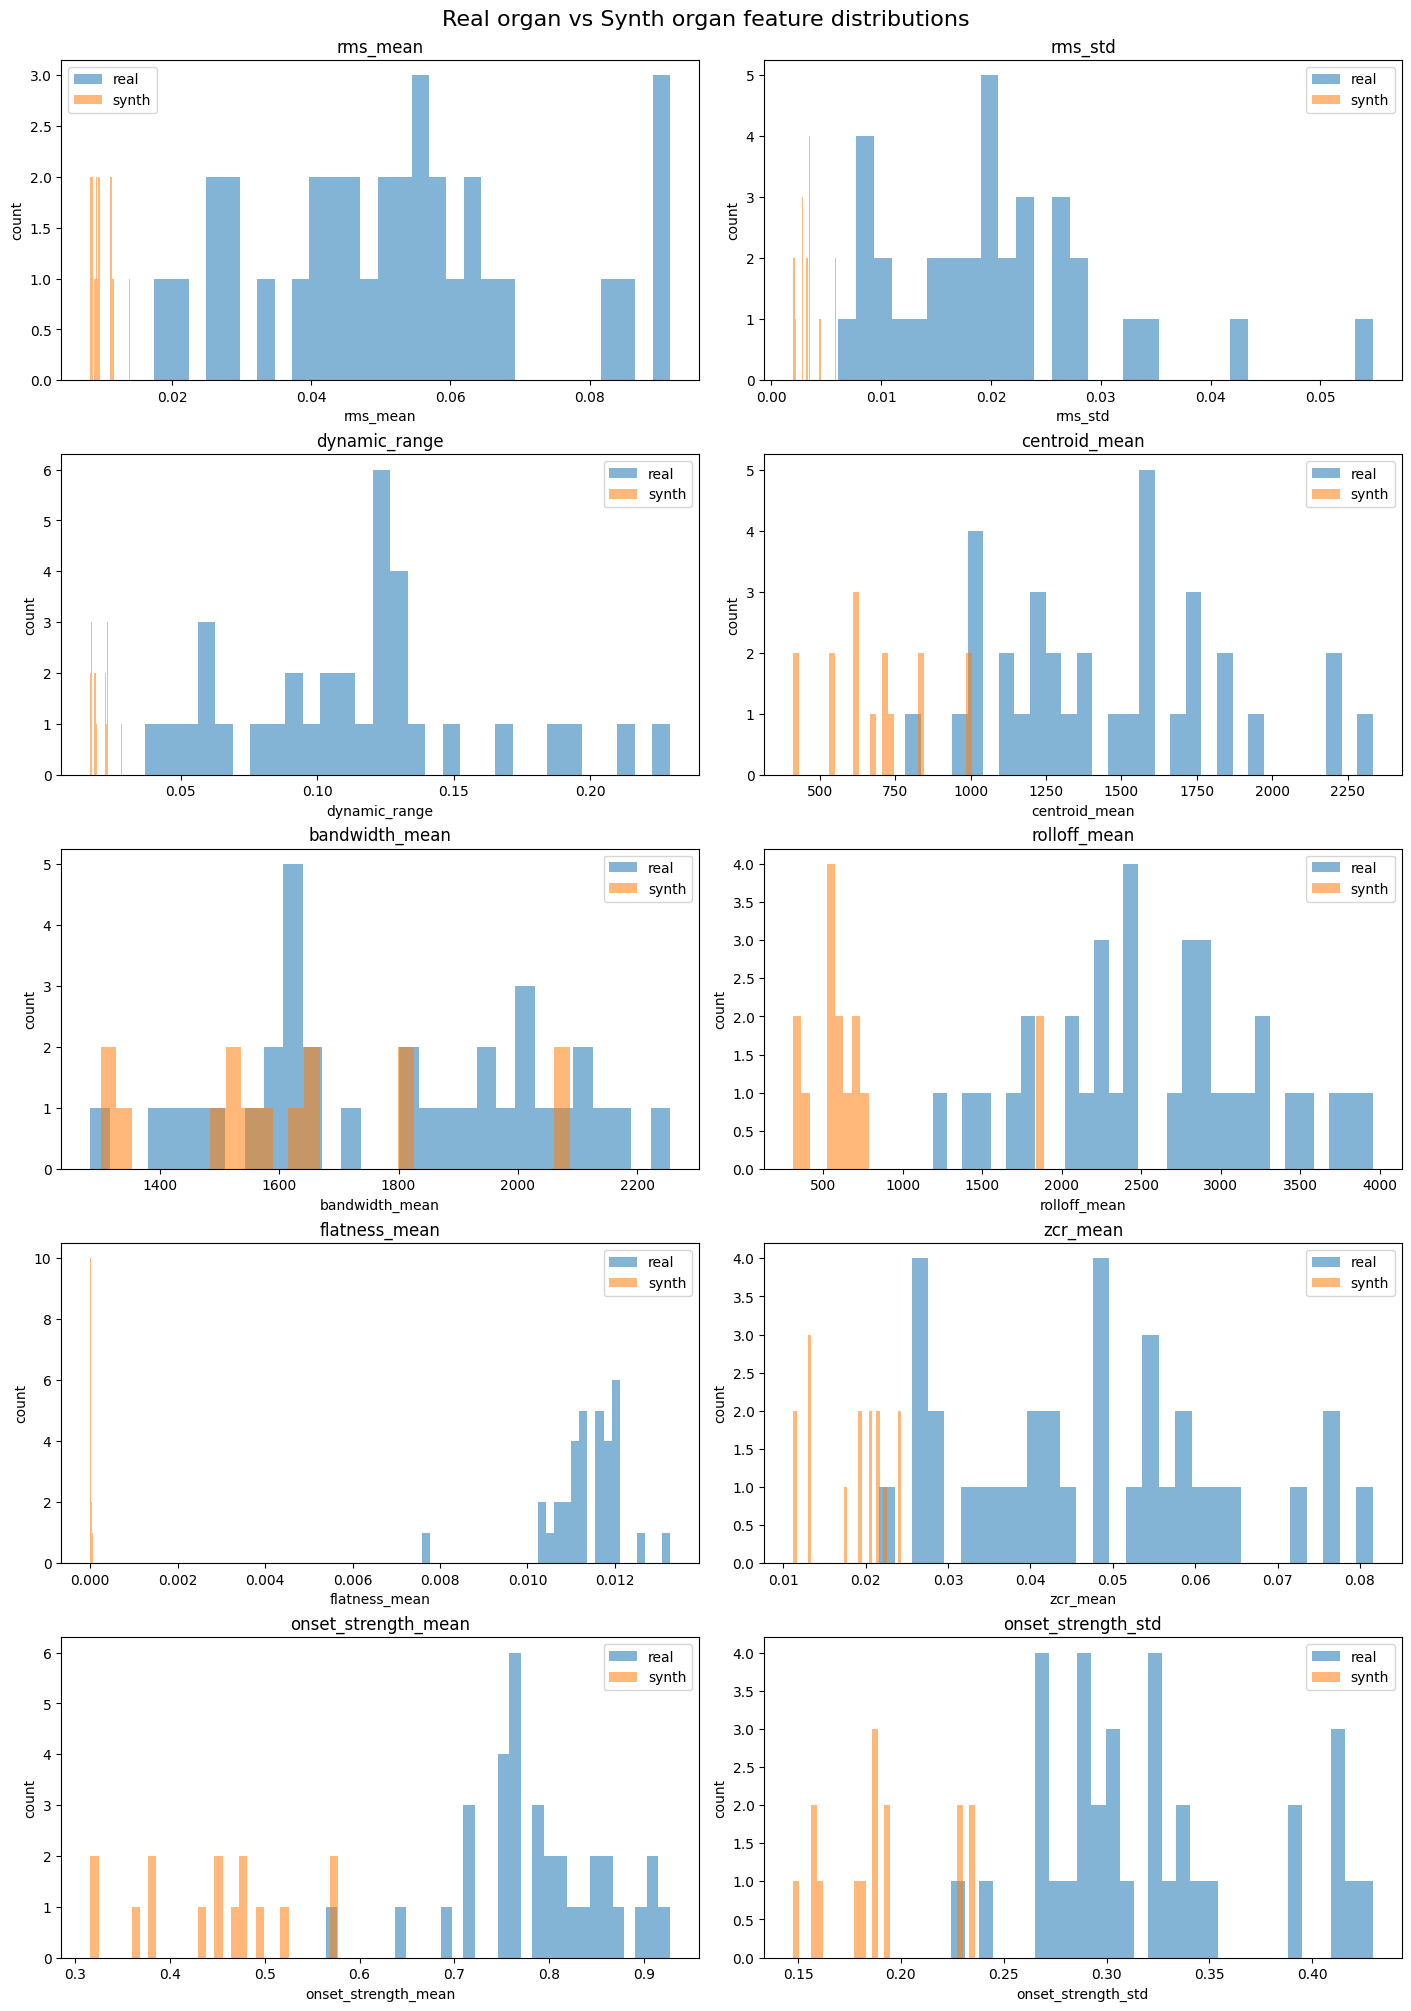

saved: D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\figures\real_vs_synth_feature_histograms.png


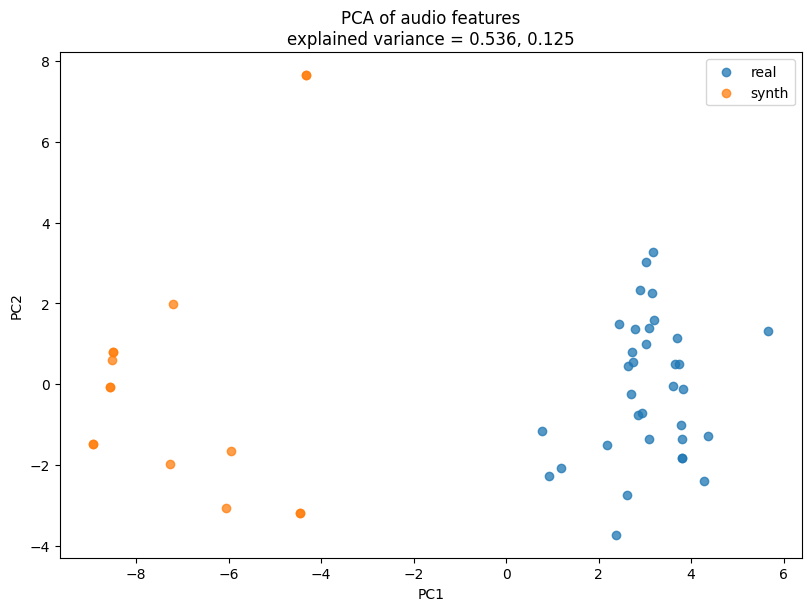

saved: D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\figures\real_vs_synth_pca.png

Finished real vs synth feature check.
Outputs:
D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_vs_synth_samples.csv
D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_vs_synth_feature_table.csv
D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_vs_synth_feature_summary.csv
D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_vs_synth_feature_distance.csv
D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\figures\real_vs_synth_feature_histograms.png
D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\figures\real_vs_synth_pca.png


In [6]:
# =========================
# 6. 检查 feat_df 是否已经成功生成特征
# =========================

print("feat_df shape:", feat_df.shape)
print("feat_df columns:")
print(feat_df.columns.tolist())

if "domain" not in feat_df.columns:
    raise ValueError("feat_df 中没有 domain 列。请先运行 real/synth 样本构造和特征提取部分。")

if "error" in feat_df.columns:
    print("\nError counts:")
    display(feat_df["error"].notna().value_counts())

    if feat_df["error"].notna().any():
        print("\nRows with errors:")
        display(
            feat_df[feat_df["error"].notna()][
                ["sample_id", "domain", "audio_path", "error"]
            ].head(20)
        )

print("\nDomain counts:")
display(feat_df["domain"].value_counts())


# =========================
# 7. 重新定义 numeric_cols
# =========================

exclude_cols = {
    "sample_id",
    "domain",
    "audio_path",
    "resolved_audio_path",
    "error",
}

numeric_cols = [
    col for col in feat_df.columns
    if col not in exclude_cols and pd.api.types.is_numeric_dtype(feat_df[col])
]

print("\nNumeric columns:")
print(numeric_cols)

if len(numeric_cols) == 0:
    raise ValueError(
        "numeric_cols 为空。说明特征提取没有成功生成数值特征。"
        "请先检查 feat_df['error'] 中的错误信息。"
    )


# =========================
# 8. 特征汇总表
# =========================

summary_rows = []

for domain, g in feat_df.groupby("domain"):
    for col in numeric_cols:
        values = g[col].dropna()

        if len(values) == 0:
            continue

        summary_rows.append({
            "domain": domain,
            "feature": col,
            "count": int(len(values)),
            "mean": float(values.mean()),
            "std": float(values.std()) if len(values) > 1 else 0.0,
            "median": float(values.median()),
            "min": float(values.min()),
            "max": float(values.max()),
        })

feature_summary = pd.DataFrame(summary_rows)

if len(feature_summary) == 0:
    print("Warning: feature_summary 为空。")
else:
    display(feature_summary.head(20))

feature_summary.to_csv(FEATURE_SUMMARY_PATH, index=False, encoding="utf-8-sig")
print("saved:", FEATURE_SUMMARY_PATH)


# =========================
# 9. real vs synth 分布距离
# =========================

from scipy.stats import ks_2samp, wasserstein_distance

distance_rows = []

for col in numeric_cols:
    real_values = feat_df.loc[feat_df["domain"] == "real", col].dropna()
    synth_values = feat_df.loc[feat_df["domain"] == "synth", col].dropna()

    real_n = len(real_values)
    synth_n = len(synth_values)

    # 两边至少各有 1 个值，才能算 Wasserstein distance
    if real_n == 0 or synth_n == 0:
        continue

    wd = wasserstein_distance(real_values, synth_values)

    # KS test 样本很小时统计意义弱，但这里可以作为参考
    if real_n >= 1 and synth_n >= 1:
        ks_result = ks_2samp(real_values, synth_values)
        ks_statistic = float(ks_result.statistic)
        ks_pvalue = float(ks_result.pvalue)
    else:
        ks_statistic = np.nan
        ks_pvalue = np.nan

    distance_rows.append({
        "feature": col,
        "real_count": int(real_n),
        "synth_count": int(synth_n),
        "real_mean": float(real_values.mean()),
        "synth_mean": float(synth_values.mean()),
        "mean_diff_real_minus_synth": float(real_values.mean() - synth_values.mean()),
        "ks_statistic": ks_statistic,
        "ks_pvalue": ks_pvalue,
        "wasserstein_distance": float(wd),
    })

distance_columns = [
    "feature",
    "real_count",
    "synth_count",
    "real_mean",
    "synth_mean",
    "mean_diff_real_minus_synth",
    "ks_statistic",
    "ks_pvalue",
    "wasserstein_distance",
]

feature_distance = pd.DataFrame(distance_rows, columns=distance_columns)

if len(feature_distance) > 0:
    feature_distance = feature_distance.sort_values(
        "wasserstein_distance",
        ascending=False,
    )
    display(feature_distance.head(20))
else:
    print("Warning: feature_distance 为空。")
    print("可能原因：real 或 synth 没有有效数值特征，或者所有特征都是 NaN。")

feature_distance.to_csv(FEATURE_DISTANCE_PATH, index=False, encoding="utf-8-sig")
print("saved:", FEATURE_DISTANCE_PATH)


# =========================
# 10. 画 real vs synth 特征分布直方图
# =========================

plot_cols = [
    "rms_mean",
    "rms_std",
    "dynamic_range",
    "centroid_mean",
    "bandwidth_mean",
    "rolloff_mean",
    "flatness_mean",
    "zcr_mean",
    "onset_strength_mean",
    "onset_strength_std",
]

plot_cols = [c for c in plot_cols if c in feat_df.columns]

if len(plot_cols) == 0:
    print("Warning: 没有可画的 plot_cols。请检查特征提取是否成功。")
else:
    n_cols = 2
    n_rows = int(np.ceil(len(plot_cols) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(14, 4 * n_rows),
        constrained_layout=True,
    )

    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, plot_cols):
        for domain in ["real", "synth"]:
            values = feat_df.loc[feat_df["domain"] == domain, col].dropna()
            ax.hist(values, bins=30, alpha=0.55, label=domain)

        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("count")
        ax.legend()

    for ax in axes[len(plot_cols):]:
        ax.axis("off")

    fig.suptitle("Real organ vs Synth organ feature distributions", fontsize=16)
    fig.savefig(HIST_FIG_PATH, dpi=150)
    plt.show()

    print("saved:", HIST_FIG_PATH)


# =========================
# 11. PCA 可视化
# =========================

pca_feature_cols = [
    c for c in numeric_cols
    if c not in {
        "file_duration_sec",
        "file_sample_rate",
        "file_channels",
        "feature_duration_sec",
    }
]

pca_df = feat_df[["sample_id", "domain"] + pca_feature_cols].copy()
pca_df = pca_df.dropna()

if len(pca_df) >= 3 and pca_df["domain"].nunique() >= 2:
    X = pca_df[pca_feature_cols].values
    X_scaled = StandardScaler().fit_transform(X)

    pca = PCA(n_components=2, random_state=42)
    Z = pca.fit_transform(X_scaled)

    pca_df["pc1"] = Z[:, 0]
    pca_df["pc2"] = Z[:, 1]

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

    for domain in ["real", "synth"]:
        sub = pca_df[pca_df["domain"] == domain]
        ax.scatter(sub["pc1"], sub["pc2"], label=domain, alpha=0.75)

    ax.set_title(
        "PCA of audio features\n"
        f"explained variance = {pca.explained_variance_ratio_[0]:.3f}, "
        f"{pca.explained_variance_ratio_[1]:.3f}"
    )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()

    fig.savefig(PCA_FIG_PATH, dpi=150)
    plt.show()

    print("saved:", PCA_FIG_PATH)

else:
    print("PCA skipped: 样本数不足、real/synth 类别不足，或特征中存在过多 NaN。")


# =========================
# 12. 最终输出
# =========================

print("\nFinished real vs synth feature check.")
print("Outputs:")
print(COMPARE_SAMPLES_PATH)
print(FEATURE_TABLE_PATH)
print(FEATURE_SUMMARY_PATH)
print(FEATURE_DISTANCE_PATH)
print(HIST_FIG_PATH)
print(PCA_FIG_PATH)

VALID_SAMPLES_PATH: D:\organ-amt-generalization\data\processed\ex01_data_check\valid_samples.csv
REAL_AUDIO_DIR: D:\organ-amt-generalization\data\raw\organ\real_organ_test
REAL_WAV_DIR: D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav
FIGURE_DIR: D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\figures
real samples : 34
synth samples: 15


,sample_id,domain,audio_path
0,BWV0531i,real,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0531i.wav
1,BWV0531ii,real,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0531ii.wav
2,BWV0532i,real,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0532i.wav
3,BWV0532ii,real,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0532ii.wav
4,BWV0533i,real,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0533i.wav


,sample_id,domain,audio_path
0,faf_gm11,synth,D:\organ-amt-generalization\data\raw\organ\ex01_bachorgan\audio\faf_gm11.wav
1,faf_gm12,synth,D:\organ-amt-generalization\data\raw\organ\ex01_bachorgan\audio\faf_gm12.wav
2,fafxgm11,synth,D:\organ-amt-generalization\data\raw\organ\ex01_bachorgan\audio\fafxgm11.wav
3,fafxgm12,synth,D:\organ-amt-generalization\data\raw\organ\ex01_bachorgan\audio\fafxgm12.wav
4,fai_hm11,synth,D:\organ-amt-generalization\data\raw\organ\ex01_bachorgan\audio\fai_hm11.wav


CQT compare pairs:


,pair_id,real_sample_id,real_audio_path,synth_sample_id,synth_audio_path
0,0,BWV0541ii,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0541ii.wav,taf_dm11,D:\organ-amt-generalization\data\raw\organ\ex01_bachorgan\audio\taf_dm11.wav
1,1,BWV0544ii,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0544ii.wav,taf_f12,D:\organ-amt-generalization\data\raw\organ\ex01_bachorgan\audio\taf_f12.wav
2,2,BWV0548ii,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0548ii.wav,faf_gm11,D:\organ-amt-generalization\data\raw\organ\ex01_bachorgan\audio\faf_gm11.wav
3,3,BWV0548i,D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_wav\BWV0548i.wav,tafxf11,D:\organ-amt-generalization\data\raw\organ\ex01_bachorgan\audio\tafxf11.wav


saved: D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\real_vs_synth_cqt_compare_samples.csv


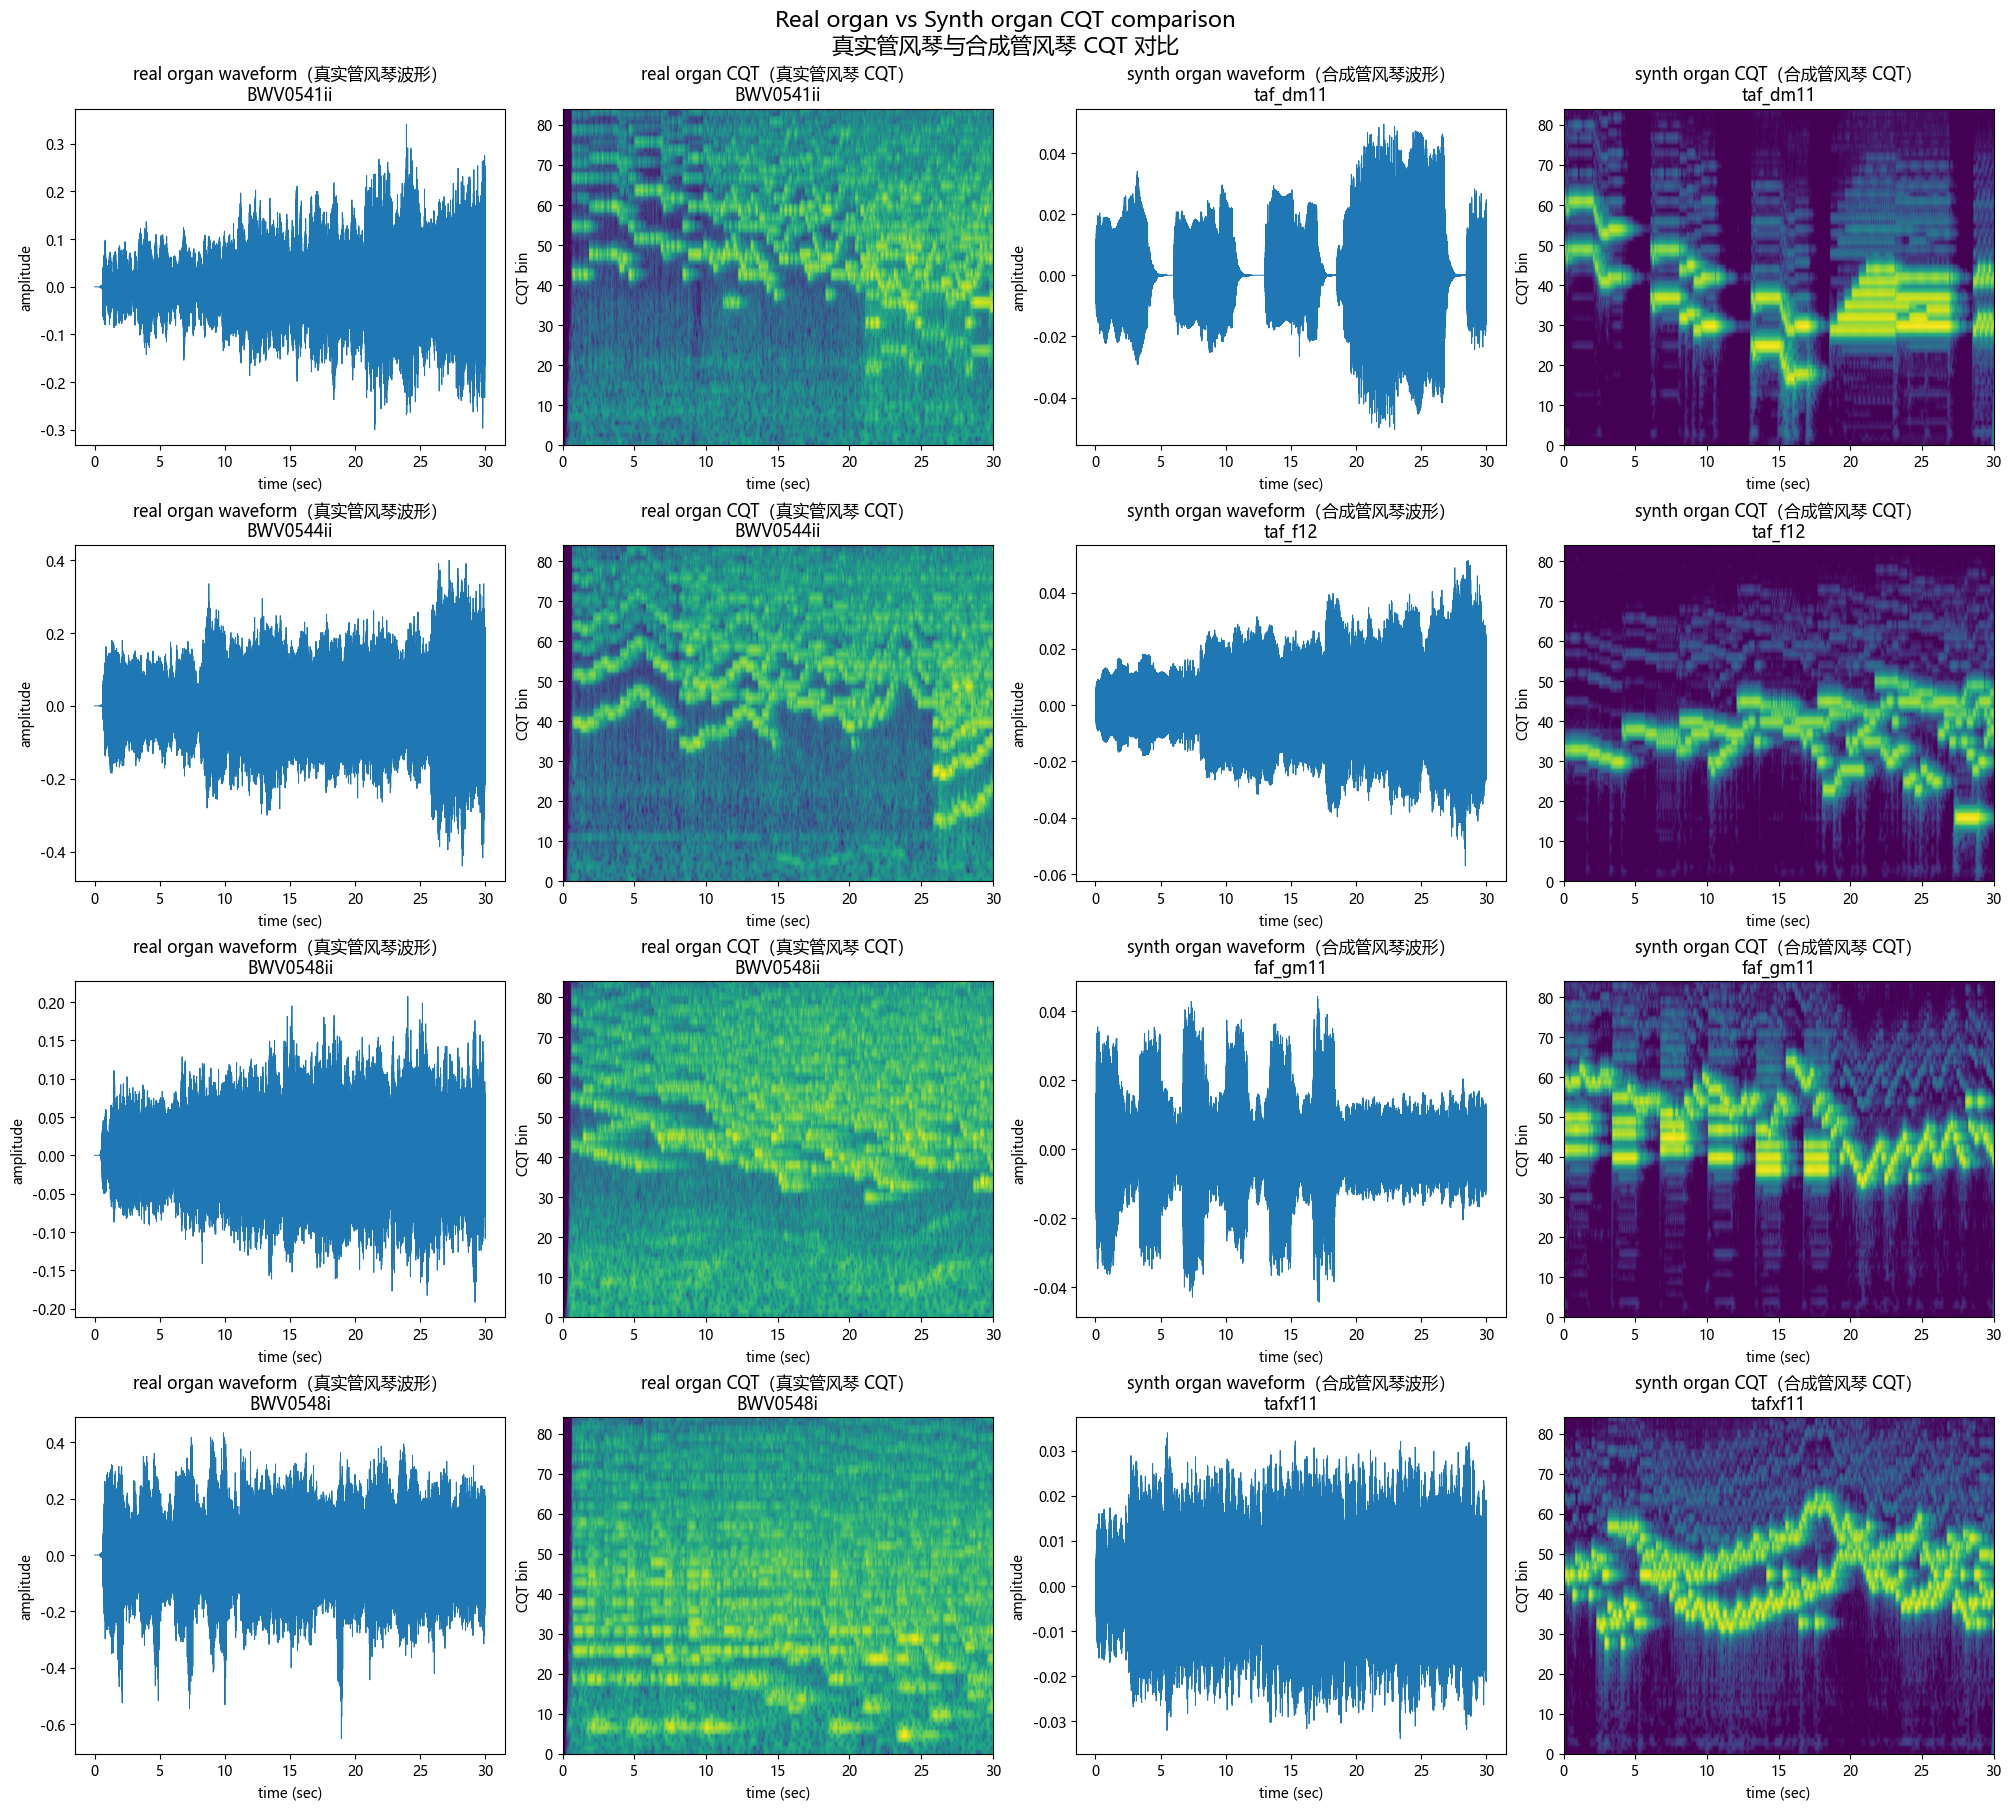

saved: D:\organ-amt-generalization\data\processed\ex01_data_check\real_vs_synth_check\figures\real_vs_synth_cqt_compare.png


In [7]:


# =========================
# 1. 路径设置
# =========================

PROJECT_ROOT = Path(r"D:\organ-amt-generalization")

PROCESSED_DIR = PROJECT_ROOT / r"data\processed\ex01_data_check"
VALID_SAMPLES_PATH = PROCESSED_DIR / "valid_samples.csv"

REAL_AUDIO_DIR = PROJECT_ROOT / r"data\raw\organ\real_organ_test"

REAL_VS_SYNTH_DIR = PROCESSED_DIR / "real_vs_synth_check"
REAL_WAV_DIR = REAL_VS_SYNTH_DIR / "real_wav"

FIGURE_DIR = REAL_VS_SYNTH_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

CQT_COMPARE_FIG_PATH = FIGURE_DIR / "real_vs_synth_cqt_compare.png"
CQT_COMPARE_SAMPLES_PATH = REAL_VS_SYNTH_DIR / "real_vs_synth_cqt_compare_samples.csv"

print("VALID_SAMPLES_PATH:", VALID_SAMPLES_PATH)
print("REAL_AUDIO_DIR:", REAL_AUDIO_DIR)
print("REAL_WAV_DIR:", REAL_WAV_DIR)
print("FIGURE_DIR:", FIGURE_DIR)

if not VALID_SAMPLES_PATH.exists():
    raise FileNotFoundError(f"找不到 valid_samples.csv: {VALID_SAMPLES_PATH}")

if not REAL_AUDIO_DIR.exists():
    raise FileNotFoundError(f"找不到真实 organ 文件夹: {REAL_AUDIO_DIR}")


# =========================
# 2. 参数设置
# =========================

RANDOM_SEED = 42
N_COMPARE = 4              # 对比几组 real/synth
SEGMENT_START_SEC = 0.0
SEGMENT_DURATION_SEC = 30.0

TARGET_SR = 44100

CQT_HOP_LENGTH = 512
CQT_BINS_PER_OCTAVE = 12
CQT_N_BINS = 84
CQT_FMIN = librosa.note_to_hz("A0")

np.random.seed(RANDOM_SEED)


# =========================
# 3. 中文字体设置
# =========================

import matplotlib as mpl

mpl.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "SimSun",
    "Arial Unicode MS",
]
mpl.rcParams["axes.unicode_minus"] = False


# =========================
# 4. 构造 real / synth 样本表
# =========================

valid_samples = pd.read_csv(VALID_SAMPLES_PATH)

# synth organ：来自 MIDI 合成 wav
synth_df = valid_samples[valid_samples["instrument"] == "organ"].copy()
synth_df["sample_id"] = synth_df["piece_id"].astype(str)
synth_df["domain"] = "synth"
synth_df["audio_path"] = synth_df["audio_path"].astype(str)
synth_df = synth_df[["sample_id", "domain", "audio_path"]].copy()

# real organ：优先使用已经转换好的 wav
real_audio_files = []

if REAL_WAV_DIR.exists():
    real_audio_files = sorted([
        p for p in REAL_WAV_DIR.rglob("*.wav")
        if p.is_file()
    ])

# 如果还没有转换好的 wav，就直接扫描原始真实 organ 文件夹
if len(real_audio_files) == 0:
    AUDIO_EXTS = {".wav", ".flac", ".mp3", ".m4a", ".ogg"}
    real_audio_files = sorted([
        p for p in REAL_AUDIO_DIR.rglob("*")
        if p.is_file() and p.suffix.lower() in AUDIO_EXTS
    ])

if len(real_audio_files) == 0:
    raise FileNotFoundError(
        f"没有找到真实 organ 音频。请检查:\n{REAL_AUDIO_DIR}\n或\n{REAL_WAV_DIR}"
    )

real_df = pd.DataFrame({
    "sample_id": [p.stem for p in real_audio_files],
    "domain": "real",
    "audio_path": [str(p) for p in real_audio_files],
})

print("real samples :", len(real_df))
print("synth samples:", len(synth_df))

display(real_df.head())
display(synth_df.head())


# =========================
# 5. 抽样
# =========================

n = min(N_COMPARE, len(real_df), len(synth_df))

real_sample = real_df.sample(n=n, random_state=RANDOM_SEED).reset_index(drop=True)
synth_sample = synth_df.sample(n=n, random_state=RANDOM_SEED).reset_index(drop=True)

compare_pairs = pd.DataFrame({
    "pair_id": list(range(n)),
    "real_sample_id": real_sample["sample_id"],
    "real_audio_path": real_sample["audio_path"],
    "synth_sample_id": synth_sample["sample_id"],
    "synth_audio_path": synth_sample["audio_path"],
})

compare_pairs.to_csv(CQT_COMPARE_SAMPLES_PATH, index=False, encoding="utf-8-sig")

print("CQT compare pairs:")
display(compare_pairs)

print("saved:", CQT_COMPARE_SAMPLES_PATH)


# =========================
# 6. 音频读取和 CQT 函数
# =========================

def resolve_audio_path(path_value):
    p = Path(str(path_value))
    if p.is_absolute():
        return p
    return PROJECT_ROOT / p


def load_audio_segment(audio_path, start_sec=0.0, duration_sec=30.0, target_sr=44100):
    audio_path = resolve_audio_path(audio_path)

    if not audio_path.exists():
        raise FileNotFoundError(f"audio not found: {audio_path}")

    y, sr = librosa.load(
        str(audio_path),
        sr=target_sr,
        mono=True,
        offset=start_sec,
        duration=duration_sec,
    )

    if len(y) == 0:
        raise ValueError(f"empty audio segment: {audio_path}")

    return y, sr


def compute_cqt_db(y, sr):
    cqt = librosa.cqt(
        y=y,
        sr=sr,
        hop_length=CQT_HOP_LENGTH,
        fmin=CQT_FMIN,
        n_bins=CQT_N_BINS,
        bins_per_octave=CQT_BINS_PER_OCTAVE,
    )

    cqt_db = librosa.amplitude_to_db(np.abs(cqt), ref=np.max)
    return cqt_db


def plot_waveform(ax, y, sr, start_sec, title):
    t = np.arange(len(y)) / sr + start_sec
    ax.plot(t, y, linewidth=0.7)
    ax.set_title(title)
    ax.set_xlabel("time (sec)")
    ax.set_ylabel("amplitude")


def plot_cqt(ax, cqt_db, start_sec, duration_sec, title):
    extent = [
        start_sec,
        start_sec + duration_sec,
        0,
        CQT_N_BINS,
    ]

    im = ax.imshow(
        cqt_db,
        origin="lower",
        aspect="auto",
        extent=extent,
    )

    ax.set_title(title)
    ax.set_xlabel("time (sec)")
    ax.set_ylabel("CQT bin")

    return im


# =========================
# 7. 生成 real vs synth CQT 对比图
# =========================

fig, axes = plt.subplots(
    n,
    4,
    figsize=(20, 4.5 * n),
    constrained_layout=True,
)

if n == 1:
    axes = np.array([axes])

for i in range(n):
    real_id = compare_pairs.loc[i, "real_sample_id"]
    real_path = compare_pairs.loc[i, "real_audio_path"]

    synth_id = compare_pairs.loc[i, "synth_sample_id"]
    synth_path = compare_pairs.loc[i, "synth_audio_path"]

    # real
    y_real, sr_real = load_audio_segment(
        real_path,
        start_sec=SEGMENT_START_SEC,
        duration_sec=SEGMENT_DURATION_SEC,
        target_sr=TARGET_SR,
    )
    cqt_real = compute_cqt_db(y_real, sr_real)

    # synth
    y_synth, sr_synth = load_audio_segment(
        synth_path,
        start_sec=SEGMENT_START_SEC,
        duration_sec=SEGMENT_DURATION_SEC,
        target_sr=TARGET_SR,
    )
    cqt_synth = compute_cqt_db(y_synth, sr_synth)

    plot_waveform(
        axes[i, 0],
        y_real,
        sr_real,
        SEGMENT_START_SEC,
        f"real organ waveform（真实管风琴波形）\n{real_id}",
    )

    plot_cqt(
        axes[i, 1],
        cqt_real,
        SEGMENT_START_SEC,
        SEGMENT_DURATION_SEC,
        f"real organ CQT（真实管风琴 CQT）\n{real_id}",
    )

    plot_waveform(
        axes[i, 2],
        y_synth,
        sr_synth,
        SEGMENT_START_SEC,
        f"synth organ waveform（合成管风琴波形）\n{synth_id}",
    )

    plot_cqt(
        axes[i, 3],
        cqt_synth,
        SEGMENT_START_SEC,
        SEGMENT_DURATION_SEC,
        f"synth organ CQT（合成管风琴 CQT）\n{synth_id}",
    )

fig.suptitle(
    "Real organ vs Synth organ CQT comparison\n真实管风琴与合成管风琴 CQT 对比",
    fontsize=16,
)

fig.savefig(CQT_COMPARE_FIG_PATH, dpi=150)
plt.show()

print("saved:", CQT_COMPARE_FIG_PATH)